## **# SCENARIO 1 – MULTINOMIAL NAÏVE BAYES**

Accuracy: 0.97847533632287
Precision: 0.9256756756756757
Recall: 0.9133333333333333
F1 Score: 0.9194630872483222
              precision    recall  f1-score   support

           0       0.99      0.99      0.99       965
           1       0.93      0.91      0.92       150

    accuracy                           0.98      1115
   macro avg       0.96      0.95      0.95      1115
weighted avg       0.98      0.98      0.98      1115



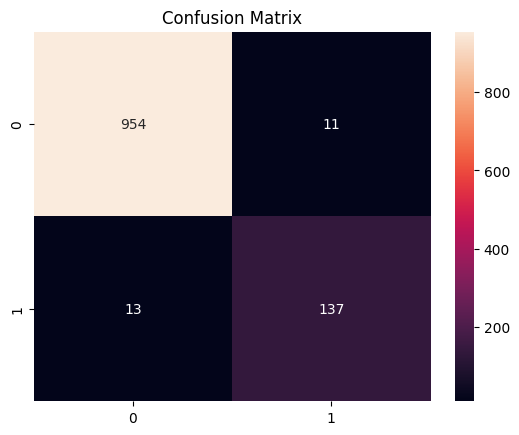

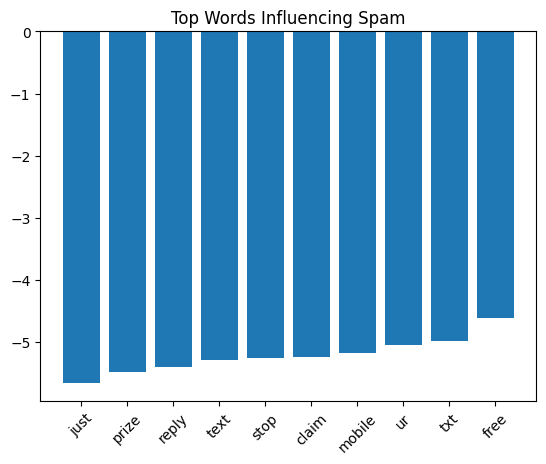

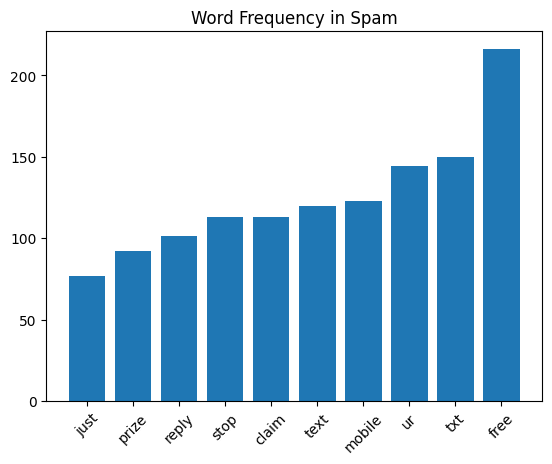

In [6]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import re
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import CountVectorizer, TfidfVectorizer
from sklearn.preprocessing import LabelEncoder
from sklearn.naive_bayes import MultinomialNB
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix, classification_report

df = pd.read_csv("spam.csv", encoding="latin-1")
df = df[['v1','v2']]
df.columns = ['label','message']

df['message'] = df['message'].str.lower()
df['message'] = df['message'].apply(lambda x: re.sub(r'[^a-zA-Z0-9\s]', '', x))

le = LabelEncoder()
df['label'] = le.fit_transform(df['label'])

vectorizer = CountVectorizer(stop_words='english')
X = vectorizer.fit_transform(df['message'])
y = df['label']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

model = MultinomialNB(alpha=1.0)
model.fit(X_train, y_train)

y_pred = model.predict(X_test)

print("Accuracy:", accuracy_score(y_test, y_pred))
print("Precision:", precision_score(y_test, y_pred))
print("Recall:", recall_score(y_test, y_pred))
print("F1 Score:", f1_score(y_test, y_pred))
print(classification_report(y_test, y_pred))

cm = confusion_matrix(y_test, y_pred)
plt.figure()
sns.heatmap(cm, annot=True, fmt='d')
plt.title("Confusion Matrix")
plt.show()

feature_names = np.array(vectorizer.get_feature_names_out())
spam_probs = model.feature_log_prob_[1]
top_spam_words = feature_names[np.argsort(spam_probs)[-10:]]

plt.figure()
plt.bar(top_spam_words, np.sort(spam_probs)[-10:])
plt.xticks(rotation=45)
plt.title("Top Words Influencing Spam")
plt.show()

spam_text = df[df['label']==1]['message']
ham_text = df[df['label']==0]['message']

spam_counts = vectorizer.transform(spam_text).sum(axis=0)
ham_counts = vectorizer.transform(ham_text).sum(axis=0)

spam_freq = np.array(spam_counts).flatten()
ham_freq = np.array(ham_counts).flatten()

top_words = feature_names[np.argsort(spam_freq)[-10:]]

plt.figure()
plt.bar(top_words, spam_freq[np.argsort(spam_freq)[-10:]])
plt.xticks(rotation=45)
plt.title("Word Frequency in Spam")
plt.show()

misclassified = X_test[(y_test != y_pred).values]

# **SCENARIO 2 – GAUSSIAN NAÏVE BAYES **

Gaussian NB Accuracy: 1.0
              precision    recall  f1-score   support

           0       1.00      1.00      1.00        10
           1       1.00      1.00      1.00         9
           2       1.00      1.00      1.00        11

    accuracy                           1.00        30
   macro avg       1.00      1.00      1.00        30
weighted avg       1.00      1.00      1.00        30



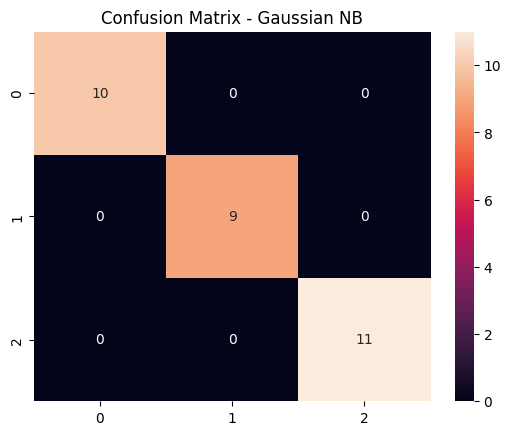

Class Probabilities (first 5):
[[5.97322611e-090 9.95635768e-001 4.36423247e-003]
 [1.00000000e+000 4.96157683e-014 6.54921950e-021]
 [7.31861098e-290 4.92947289e-012 1.00000000e+000]
 [2.81838335e-094 9.77593560e-001 2.24064404e-002]
 [1.13876385e-105 8.70022604e-001 1.29977396e-001]]
Logistic Regression Accuracy: 1.0


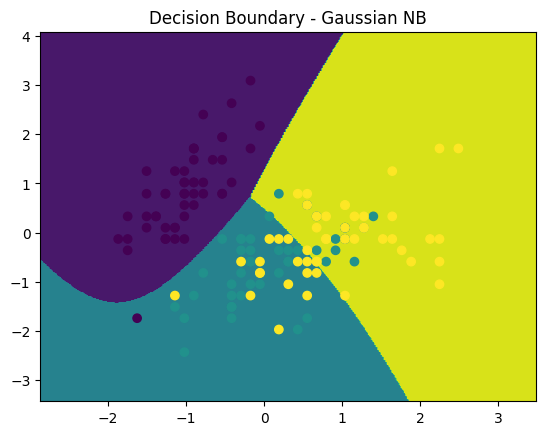

In [7]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.datasets import load_iris
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.naive_bayes import GaussianNB
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

iris = load_iris()
X = iris.data
y = iris.target

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

X_train, X_test, y_train, y_test = train_test_split(X_scaled, y, test_size=0.2, random_state=42)

gnb = GaussianNB()
gnb.fit(X_train, y_train)

y_pred = gnb.predict(X_test)

print("Gaussian NB Accuracy:", accuracy_score(y_test, y_pred))
print(classification_report(y_test, y_pred))

cm = confusion_matrix(y_test, y_pred)
plt.figure()
sns.heatmap(cm, annot=True, fmt='d')
plt.title("Confusion Matrix - Gaussian NB")
plt.show()

probs = gnb.predict_proba(X_test)
print("Class Probabilities (first 5):")
print(probs[:5])

log_reg = LogisticRegression()
log_reg.fit(X_train, y_train)
y_pred_lr = log_reg.predict(X_test)

print("Logistic Regression Accuracy:", accuracy_score(y_test, y_pred_lr))

X_vis = X_scaled[:, :2]
X_train_v, X_test_v, y_train_v, y_test_v = train_test_split(X_vis, y, test_size=0.2, random_state=42)

gnb_v = GaussianNB()
gnb_v.fit(X_train_v, y_train_v)

x_min, x_max = X_vis[:, 0].min() - 1, X_vis[:, 0].max() + 1
y_min, y_max = X_vis[:, 1].min() - 1, X_vis[:, 1].max() + 1
xx, yy = np.meshgrid(np.arange(x_min, x_max, 0.02),
                     np.arange(y_min, y_max, 0.02))

Z = gnb_v.predict(np.c_[xx.ravel(), yy.ravel()])
Z = Z.reshape(xx.shape)

plt.figure()
plt.contourf(xx, yy, Z)
plt.scatter(X_vis[:, 0], X_vis[:, 1], c=y)
plt.title("Decision Boundary - Gaussian NB")
plt.show()